# Coplanar Wave guide 

[scikit-rf (aka skrf) is an Open Source, BSD-licensed package for RF/Microwave engineering implemented in the Python programming language](https://scikit-rf.readthedocs.io/en/latest/).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
path_fig="..//Figures/"
path_Sonnet="..//Sonnet/"

## On considère une ligne CPW (lageur $w=17 \, \mu \mathrm{m}$, gap $g=10 \, \mu \mathrm{m}$) simulée avec SONNET sur un substrat de $500 \, \mu \mathrm{m}$  

- La ligne CPW est simulée entre 0.1 et 10 GHZ dans une boite de $6.2 \,\mathrm{mm} \times 634 \,\mu\mathrm{m} $ avec une Cell size $(10 \mu \times 1 \mu)$ adaptée à la géométrie de la ligne,
- Les ports 1 et 2 ont une impédance de $50 \, \Omega$ et les plan de références sont positionnés à $100 \, \mu m$ des bords,
- La simulation génère 6 fichiers s2p correspondant à des couches métallique d'inductance cinétique  de $L_{k}= 0 \, \mathrm{pH/sp}$,  $0.2 \, \mathrm{pH/sp}$, ... et , $1 \, \mathrm{pH/sp}$,  
- Charger les 6 fichiers "CPW_param#.s2p générés par Sonnet.

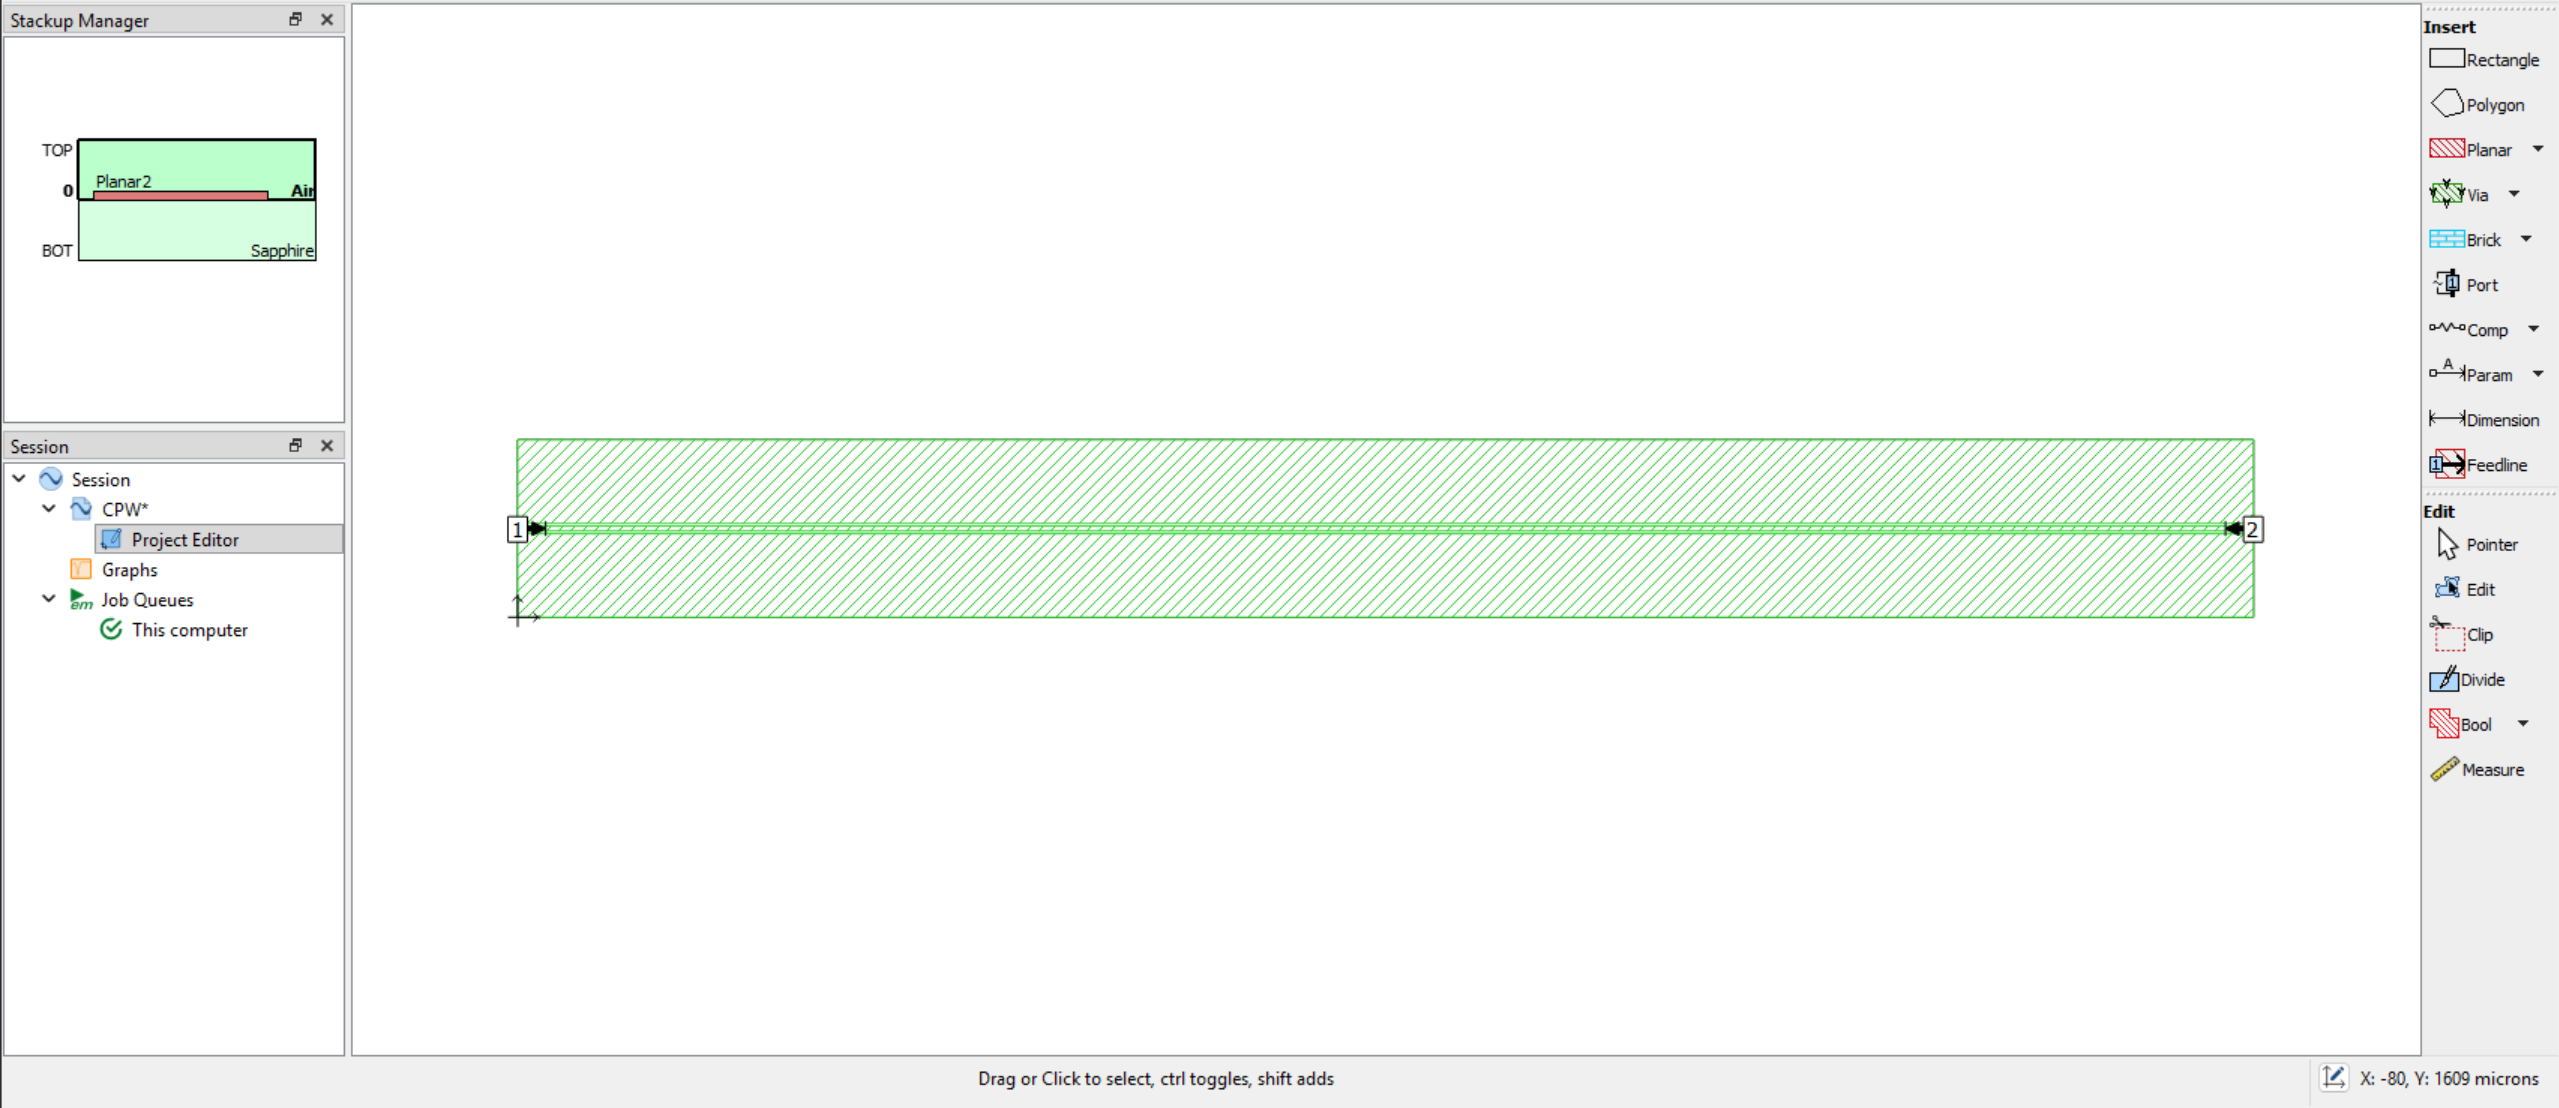

In [2]:
Image(filename=path_fig+"Sonnet_CPW.png", width=600)

- Tracer les paramètres de scattering $S_{11}$ et $S_{12}$ pour l'ensemble des lignes  (on pourra extraire l'ensemble des fréquence simulées de la structure [skrf](https://scikit-rf.readthedocs.io/en/latest/))
- Déduire de $\mathrm{Arg} \, S_{21}$ la vitesse $v$ de propagation du  signal le long de la microstip,
- Déduire de la matrice de transmission ABCD l'impédance caractéristique $Z_c$ de la ligne de transmission,
- Déduire de $v$ et $Z_c$ les capacité et indictance linéique de la ligne (on retiendra les valeurs pour une couche d'inductance cinétique de 0.2 pH/sq),
- Retrouver l'inductance cinétique ainsi que l'inductance électromagnétique?
  

Définition d'une structure [SciKitRF](https://scikit-rf.readthedocs.io/en/latest/):

In [5]:
CPW0=rf.Network("..//Sonnet/CPW_param1.s2p")

In [6]:
Param=['0 pH','0.2 pH','0.4 pH','0.6 pH','0.8 pH', '1 pH']

In [11]:
CPW = []
for i in range(1,7):
    file_name =path_Sonnet+"/CPW_param"+ str(i)+".s2p"
    CPW.append(rf.Network(file_name))
freq=CPW[2].frequency.f

[Text(0.5, 0, 'frequency (GHz)'), Text(0, 0.5, '$Arg \\, S_{21}$')]

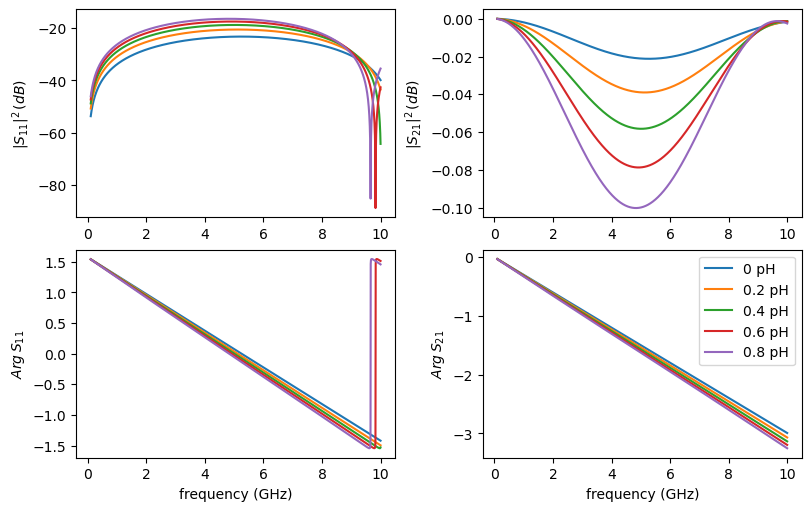

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(8, 5), constrained_layout=True)
#fig.suptitle('Vertically stacked subplots')
for k in range(0,5):
    axs[0,0].plot(1e-9*freq,20*np.log10(np.abs(CPW[k].s[:,0,0])), label=Param[k])
    axs[1,0].plot(1e-9*freq,np.unwrap(np.angle(CPW[k].s[:,0,0])), label=Param[k])
    axs[0,1].plot(1e-9*freq,20*np.log10(np.abs(CPW[k].s[:,1,0])), label=Param[k])
    axs[1,1].plot(1e-9*freq,np.unwrap(np.angle(CPW[k].s[:,1,0])), label=Param[k])
plt.legend()
axs[0,0].set(ylabel="$|S_{11}|^2 \, (dB)$")
axs[0,1].set(ylabel="$|S_{21}|^2 \, (dB)$")
axs[1,0].set(xlabel="frequency (GHz)", ylabel="$Arg \, S_{11}$")
axs[1,1].set(xlabel="frequency (GHz)", ylabel="$Arg \, S_{21}$")

### Velocity

In [13]:
L0=6e-3 # line length (between calibrated ports)
poly=np.zeros(shape=(6, 2))
for i in range(0,6):
    poly[i,:]=np.polyfit(freq, np.unwrap(np.angle(CPW[i].s[:,0,1])), 1)
print(poly)

[[-2.99151531e-10 -1.46142964e-03]
 [-3.06599068e-10 -2.49144270e-03]
 [-3.12984532e-10 -3.52472581e-03]
 [-3.18789781e-10 -4.53520196e-03]
 [-3.24211776e-10 -5.51278214e-03]
 [-3.29356672e-10 -6.44242490e-03]]


In [14]:
v_g=(abs(2*np.pi*L0/poly[:,0]))
epsilon_eff=(3e8/v_g)**2

In [15]:
print('groupe velocity=' + str(np.round(1e-8*v_g,2)) +'e8 m/s')
print('\\epsilon_{eff}=' + str(np.round((3e8/v_g)**2,2)))

groupe velocity=[1.26 1.23 1.2  1.18 1.16 1.14]e8 m/s
\epsilon_{eff}=[5.67 5.95 6.2  6.44 6.66 6.87]


### Characteristic impedance

La matrice de transfert d'une ligne de propagation est $
\begin{pmatrix}
A & B \\
C & D
\end{pmatrix}
= \begin{pmatrix}
\cos kL & iZ_c\sin kL \\
i\frac{\sin kL}{Z_c} &\cos kL
\end{pmatrix}
$. On en déduit $Z_c=\sqrt{\frac{B}{C}}$

In [21]:
Zc=np.zeros(shape=(len(freq), 6))
for k in range(0,6):
        Zc[:,k] = np.sqrt(np.imag(CPW[k].a[:, 0, 1])/np.imag(CPW[k].a[:, 1, 0]))

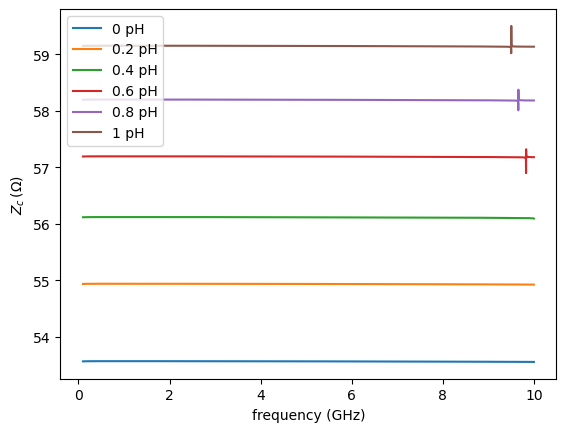

In [22]:
plt.figure()
for i in range(6):
     plt.plot(1e-9*freq,Zc[:,i], label=Param[i])
     plt.legend(loc="upper left")
     plt.xlabel("frequency (GHz)")
     plt.ylabel("$Z_c \, (\Omega)$")
plt.show()    
     

In [25]:
np.mean(Zc[:,1])

np.float64(54.93373783415943)

In [26]:
print('Zc=' + str(np.round(np.mean(Zc[:,1]),2)) +' Ohms')

Zc=54.93 Ohms


### inductance $\mathcal{L}$ et capacité $\mathcal{C}$ linéique

Les expression de $v$ et $Z_c$ donnent $\mathcal{L}=\frac{Z_c}{v}$ et $\mathcal{C}=\frac{1}{Z_cv}$.

In [18]:
Llin=np.mean(Zc)/v_g
Clin=1/(np.mean(Zc)*v_g)
w=17e-6

C:\Users\gabelli\AppData\Local\Temp\ipykernel_14880\3084163774.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


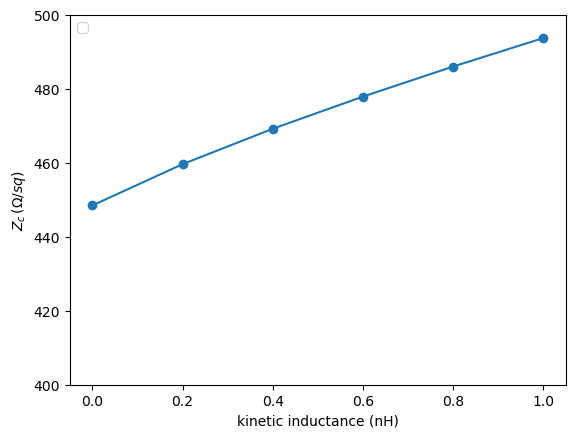

In [19]:
plt.figure()
plt.plot(np.linspace(0,1,6),1e9*Llin, marker='o', linestyle='-')
plt.legend(loc="upper left")
plt.xlabel("kinetic inductance (nH)")
plt.ylabel("$Z_c \, (\Omega/sq)$")
plt.ylim(400, 500)
plt.show()    
     